In [1]:
# Import the required libraries
# pandas is used for reading and handling the dataset
# numpy is used for the numerical values of the dataset

import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

# load the dataset into the program containing the information on telecom
# customer churn
# The path below is the exact location of my CSV file in my personal Google Drive
df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()
# This is to display the first five rows of the dataset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# this is for dataset exploration
# shape represent how many number of rows and columns there are
# info shows the column names, different data types, and non-null counts
# isnull().sum() is used for checking missing values in every column

print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Variable Distribution:")
print(df["Churn"].value_counts())

Dataset Shape:
(7043, 20)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 

In [3]:
# The customer ID feature was removed manually before ML implementation
# Converting string object TotalCharges into numeric values instead
# errors='coerce' changes any invalid or blank values into NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
# This is used to fill missing TotalCharges values using the median value
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
# Confirm that missing values have been handled
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [4]:
# Performing outlier handling using the IQR method
# It is calculated as Q3 - Q1, where:
# Q1 is the 25th percentile
# Q3 is the 75th percentile
# Values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR are treated as outliers.
# SeniorCitizen is not included as it is a binary categorial variable
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
# Create an empty list to store outlier calculation details
outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Count outliers before handling
    outliers_before = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    # Here we cap the outliers instead of deleting them
    # The values below the lower bound is replaced by lower bound
    # and vice versa for the upper bound
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    # Count outliers after capping
    outliers_after = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    # Store the results for reporting
    outlier_summary.append({
        "Column": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outliers Before": outliers_before,
        "Outliers After": outliers_after})
# Convert the outlier summary into a displayed dataframe
outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers Before,Outliers After
0,tenure,9.00,55.00,46.00,-60.00,124.00,0,0
1,MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0,0
2,TotalCharges,402.22,3786.60,3384.38,-4674.34,8863.16,0,0


In [5]:
# This is to convert the target variable into binary format as ML read 0/1
# instead of yes/no (Label Encoding)
# Yes = 1 (customer has churned)
# No = 0 (customer has retained)
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0})
# Verify the conversion
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [6]:
# Convert categorical variables into numerical format as encoding
# and this is because it is in object format and for a telco dataset it should be in numerical format
# "pd.get_dummies" is used instead of One-hot encode as it is more suitable
# in handling these type of categorical variables seen in this telco dataset
df_encoded = pd.get_dummies(
    df,
    drop_first=True)
print(df_encoded.shape)
df_encoded.head()

(7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [7]:
# Here we separate both the features and the target variable for the algorithms
# The independant variables are set to "X" and the dependant (target) set to "Y"
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]
print(X.shape)
print(y.shape)

(7043, 30)
(7043,)


In [8]:
# Here starts the important training and testing logic
# The split size is set to 80/20 as this will give us the best result during training and testing
from sklearn.model_selection import train_test_split

# "stratify.y" is used for perserving the churn distribution
# meaning that the proportion of the churned/non churned customers remain similar in both sets (train/test)
# This is especially important for the telco dataset because there is a greater number of non churned customers than churned customers
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y )
print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (5634, 30)
Testing Set : (1409, 30)


In [9]:
from sklearn.preprocessing import StandardScaler
# This is feature scaling and it is especially important for the KNN algorithm later
# as the KNN algorithm uses distance calculations
# What this does is it standardizes the values of the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(5634, 30)
(1409, 30)


In [10]:
# DecisionTreeClassifier is used for the Decision Tree model
# KNeighborsClassifier is used for the KNN model
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [11]:
# Start the training of the initial Decision Tree model without tuning
# random_state=42 as a baseline ensures that the result remains reproducible
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
# Predict the churn values using the testing data
dt_pred = dt_model.predict(X_test)

In [12]:
# Start the training of the initial K-Nearest Neighbor model without tuning
# n_neighbors=5 is used as the initial baseline value for K
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Predict churn values using the scaled testing data
knn_pred = knn_model.predict(X_test_scaled)

In [13]:
# Import the accuracy, precision, recall, f1, classification report evaluation metrics
# These metrics will be used to compare the performance of both algorithms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [14]:
# Create a function to evaluate the model performances
# This avoids repeating the same evaluation code for each algorithm
# and it will be used to save time and logic space
def evaluate_model(model_name, y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(model_name)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [15]:
# Evaluate the performance of the Decision Tree model
evaluate_model("Decision Tree Classifier", y_test, dt_pred)

Decision Tree Classifier
Accuracy : 0.7416607523066004
Precision: 0.5138888888888888
Recall   : 0.4946524064171123
F1-Score : 0.5040871934604905

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1035
           1       0.51      0.49      0.50       374

    accuracy                           0.74      1409
   macro avg       0.67      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409



In [16]:
# Evaluate KNN model performance
evaluate_model("K-Nearest Neighbor Classifier", y_test, knn_pred)

K-Nearest Neighbor Classifier
Accuracy : 0.7473385379701917
Precision: 0.5252808988764045
Recall   : 0.5
F1-Score : 0.5123287671232877

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1035
           1       0.53      0.50      0.51       374

    accuracy                           0.75      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.75      0.75      1409



From these results, we can see that both models acheived around **74% accuracy** before any hyperparameter tuning.

The KNN model performed slightly better than the Decision Tree model in terms of metrics, however both models are achieving a low F1-score and recall, meaning both models are struggling to detect churned customers properly.

This could be because of imbalanced data in the Telco dataset, which is why hyperparameter tuning will be applied to improve the performances of both models for final critical evaluation.

In [19]:
# Testing different max_depth values and best criteria for Decision Tree
# This shows how using gini at max_depth=7 was selected based on testing accuracy.
# This allows us to get a table that represents the accuracies
depth_results = []
for criterion in ["gini", "entropy"]:
  for depth in range(2, 11):
      dt_test = DecisionTreeClassifier(
          criterion=criterion,
          max_depth=depth,
          random_state=42)
      dt_test.fit(X_train, y_train)
      dt_test_pred = dt_test.predict(X_test)
      depth_results.append({
          "Criterion": criterion,
          "max_depth": depth,
          "Accuracy": round(accuracy_score(y_test, dt_test_pred) * 100, 2)})
depth_results = pd.DataFrame(depth_results)
depth_results


,Criterion,max_depth,Accuracy
0,gini,2,78.71
1,gini,3,78.71
2,gini,4,79.56
3,gini,5,79.42
4,gini,6,79.70
5,gini,7,79.06
6,gini,8,78.00
7,gini,9,77.36
8,gini,10,75.59
9,entropy,2,73.46


In [25]:
# Hyperparameter tuning for improving the intial Decision Tree model
# The max_depth of 6 using gini criteria is used after testing which depth performs the best
# for the Decision Tree model
# By applying this tuning, we can reduce the overall overfitting of the model
# and improve the final test accuracy
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    random_state=42)
dt_model.fit(X_train, y_train)
dt_new_pred = dt_model.predict(X_test)
evaluate_model("Tuned Decision Tree", y_test, dt_new_pred)

Tuned Decision Tree
Accuracy : 0.7970191625266146
Precision: 0.6746031746031746
Recall   : 0.45454545454545453
F1-Score : 0.5431309904153354

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1035
           1       0.67      0.45      0.54       374

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



After applying tuning on the max_depth parameter, the Decision Tree model accuracy improved from 74% to almost 80%, marking almost a 6% accuracy gain. The best depth to use was seen as 7. By using this depth, precision and f1-scores also improved, highlighting that the tuned model makes better churn predictions.

In [26]:
# Testing different K values for KNN
# This shows how the best K value was selected based on testing accuracy.
# The k value is then taken and used in the tuning of the KNN model
# for the best results

k_results = []
for k in range(1, 51):
    knn_test = KNeighborsClassifier(
        n_neighbors=k,
        weights="uniform",
        metric="manhattan")
    knn_test.fit(X_train_scaled, y_train)
    knn_test_pred = knn_test.predict(X_test_scaled)
    k_results.append({
        "K Value": k,
        "Accuracy": round(accuracy_score(y_test, knn_test_pred) * 100, 2)})

k_results = pd.DataFrame(k_results)
k_results
# Show the best K value based on accuracy
k_results.loc[k_results["Accuracy"].idxmax()]

,48
K Value,49.00
Accuracy,78.85


In [28]:
# Hyperparameter tuning for KNN model
# Previously, only one k value was used as a baseline which gave the initial
# KNN perfornance, which is why after testing different k-values
# n_neighbors=49 was selected because it produced the best performance during testing.
# Manhattan distance is used as the distance metric and weights are uniform
# for equal contribution of all selected neighbours.
knn_model = KNeighborsClassifier(
    n_neighbors=49,
    weights="uniform",
    metric="manhattan")

knn_model.fit(X_train_scaled, y_train)
knn_new_pred = knn_model.predict(X_test_scaled)
evaluate_model("Tuned K-Nearest Neighbor", y_test, knn_new_pred)

Tuned K-Nearest Neighbor
Accuracy : 0.7885024840312278
Precision: 0.6032608695652174
Recall   : 0.5935828877005348
F1-Score : 0.5983827493261455

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1035
           1       0.60      0.59      0.60       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [29]:
import pandas as pd
# Extract feature importance scores from the tuned Decision Tree
# which shows which feature has the most significance in the training
# & testing of the model
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_})

importance = importance.sort_values(
    by="Importance",
    ascending=False)
importance.head(15)

,Feature,Importance
1,tenure,0.390072
10,InternetService_Fiber optic,0.327698
3,TotalCharges,0.059424
28,PaymentMethod_Electronic check,0.034523
2,MonthlyCharges,0.032998
25,Contract_Two year,0.024818
9,MultipleLines_Yes,0.021658
12,OnlineSecurity_No internet service,0.018943
24,Contract_One year,0.016188
14,OnlineBackup_No internet service,0.015928


In [51]:
# Applying feature reduction on the algorithms
# The top features are selected using Decision Tree feature importance.
# This experiment checks whether using fewer important features improves model performance.
feature_counts = [5, 10, 15, 20]
feature_reduction_results = []
for n in feature_counts:
    selected_features = importance.head(n)["Feature"].tolist()
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]

    # Scaling is applied for KNN because it is distance-based
    scaler_selected = StandardScaler()
    X_train_selected_scaled = scaler_selected.fit_transform(X_train_selected)
    X_test_selected_scaled = scaler_selected.transform(X_test_selected)
    # Decision Tree using selected features
    dt_selected = DecisionTreeClassifier(
        criterion="gini",
        max_depth=6,
        random_state=42)
    dt_selected.fit(X_train_selected, y_train)
    dt_selected_pred = dt_selected.predict(X_test_selected)
    # KNN using selected features
    knn_selected = KNeighborsClassifier(
        n_neighbors=49,
        weights="uniform",
        metric="manhattan")
    knn_selected.fit(X_train_selected_scaled, y_train)
    knn_selected_pred = knn_selected.predict(X_test_selected_scaled)

    feature_reduction_results.append({
        "Top Features Used": n,
        "Decision Tree Accuracy": round(accuracy_score(y_test, dt_selected_pred) * 100, 2),
        "KNN Accuracy": round(accuracy_score(y_test, knn_selected_pred) * 100, 2)})
feature_reduction_results = pd.DataFrame(feature_reduction_results)
feature_reduction_results

,Top Features Used,Decision Tree Accuracy,KNN Accuracy
0,5,79.77,78.92
1,10,79.77,79.84
2,15,79.70,79.70
3,20,79.70,79.06


In [52]:
# Using the reduced features to create reduced DT and KNN
# Based on the feature reduction, the top 5 features are used for Decision Tree
# and the top 10 features are used for KNN.
dt_selected_features = importance.head(5)["Feature"].tolist()
knn_selected_features = importance.head(10)["Feature"].tolist()
# Feature reduced Decision Tree
X_train_dt_selected = X_train[dt_selected_features]
X_test_dt_selected = X_test[dt_selected_features]
dt_reduced = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    random_state=42)
dt_reduced.fit(X_train_dt_selected, y_train)
dt_reduced_pred = dt_reduced.predict(X_test_dt_selected)

# Feature reduced KNN
X_train_knn_selected = X_train[knn_selected_features]
X_test_knn_selected = X_test[knn_selected_features]
scaler_reduced = StandardScaler()
X_train_knn_selected_scaled = scaler_reduced.fit_transform(X_train_knn_selected)
X_test_knn_selected_scaled = scaler_reduced.transform(X_test_knn_selected)
knn_reduced = KNeighborsClassifier(
    n_neighbors=49,
    weights="uniform",
    metric="manhattan")
knn_reduced.fit(X_train_knn_selected_scaled, y_train)
knn_reduced_pred = knn_reduced.predict(X_test_knn_selected_scaled)

evaluate_model("Reduced-Feature Decision Tree", y_test, dt_reduced_pred)
print("\n")
evaluate_model("Reduced-Feature KNN", y_test, knn_reduced_pred)

Reduced-Feature Decision Tree
Accuracy : 0.7977288857345636
Precision: 0.6498316498316499
Recall   : 0.516042780748663
F1-Score : 0.5752608047690015

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



Reduced-Feature KNN
Accuracy : 0.7984386089425124
Precision: 0.6510067114093959
Recall   : 0.5187165775401069
F1-Score : 0.5773809523809523

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [50]:
# Final comparison table
# This table compares the performance of the initial and the tuned models.

final_comparison = pd.DataFrame({
    "Algorithm": [
        "Initial Decision Tree",
        "Initial KNN",
        "Tuned Decision Tree",
        "Tuned KNN",
        "Feature Reduced Decision tree",
        "Feature Reduced KNN"],
    "Accuracy": [
        round(accuracy_score(y_test, dt_pred) * 100, 2),
        round(accuracy_score(y_test, knn_pred) * 100, 2),
        round(accuracy_score(y_test, dt_new_pred) * 100, 2),
        round(accuracy_score(y_test, knn_new_pred) * 100, 2),
        round(accuracy_score(y_test, dt_reduced_pred) * 100, 2),
        round(accuracy_score(y_test, knn_reduced_pred) * 100, 2)],

    "Precision": [
        round(precision_score(y_test, dt_pred) * 100, 2),
        round(precision_score(y_test, knn_pred) * 100, 2),
        round(precision_score(y_test, dt_new_pred) * 100, 2),
        round(precision_score(y_test, knn_new_pred) * 100, 2),
        round(precision_score(y_test, dt_reduced_pred) * 100, 2),
        round(precision_score(y_test, knn_reduced_pred) * 100, 2)],

    "Recall": [
        round(recall_score(y_test, dt_pred) * 100, 2),
        round(recall_score(y_test, knn_pred) * 100, 2),
        round(recall_score(y_test, dt_new_pred) * 100, 2),
        round(recall_score(y_test, knn_new_pred) * 100, 2),
        round(recall_score(y_test, dt_reduced_pred) * 100, 2),
        round(recall_score(y_test, knn_reduced_pred) * 100, 2)],

    "F1-Score": [
        round(f1_score(y_test, dt_pred) * 100, 2),
        round(f1_score(y_test, knn_pred) * 100, 2),
        round(f1_score(y_test, dt_new_pred) * 100, 2),
        round(f1_score(y_test, knn_new_pred) * 100, 2),
        round(f1_score(y_test, dt_reduced_pred) * 100, 2),
        round(f1_score(y_test, knn_reduced_pred) * 100, 2)]})
final_comparison

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Initial Decision Tree,74.17,51.39,49.47,50.41
1,Initial KNN,74.73,52.53,50.00,51.23
2,Tuned Decision Tree,79.70,67.46,45.45,54.31
3,Tuned KNN,78.85,60.33,59.36,59.84
4,Feature Reduced Decision tree,79.77,64.98,51.60,57.53
5,Feature Reduced KNN,79.84,65.10,51.87,57.74


In [53]:
from sklearn.metrics import ConfusionMatrixDisplay

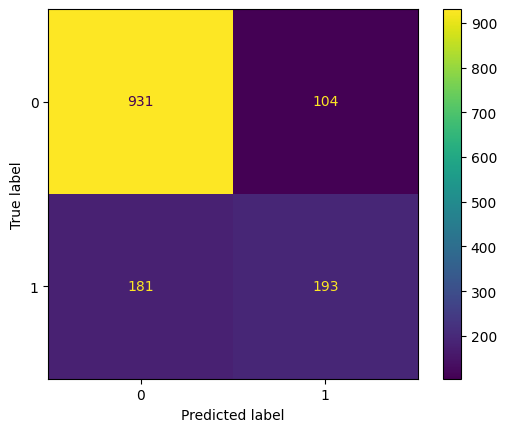

In [54]:
# Feature reduced Decision Tree Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, dt_reduced_pred)

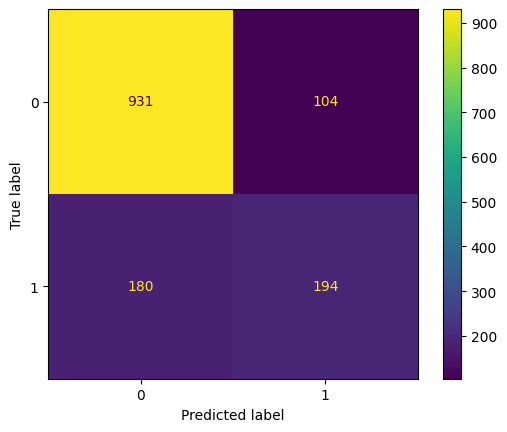

In [55]:
# Feature reduced KNN Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, knn_reduced_pred)

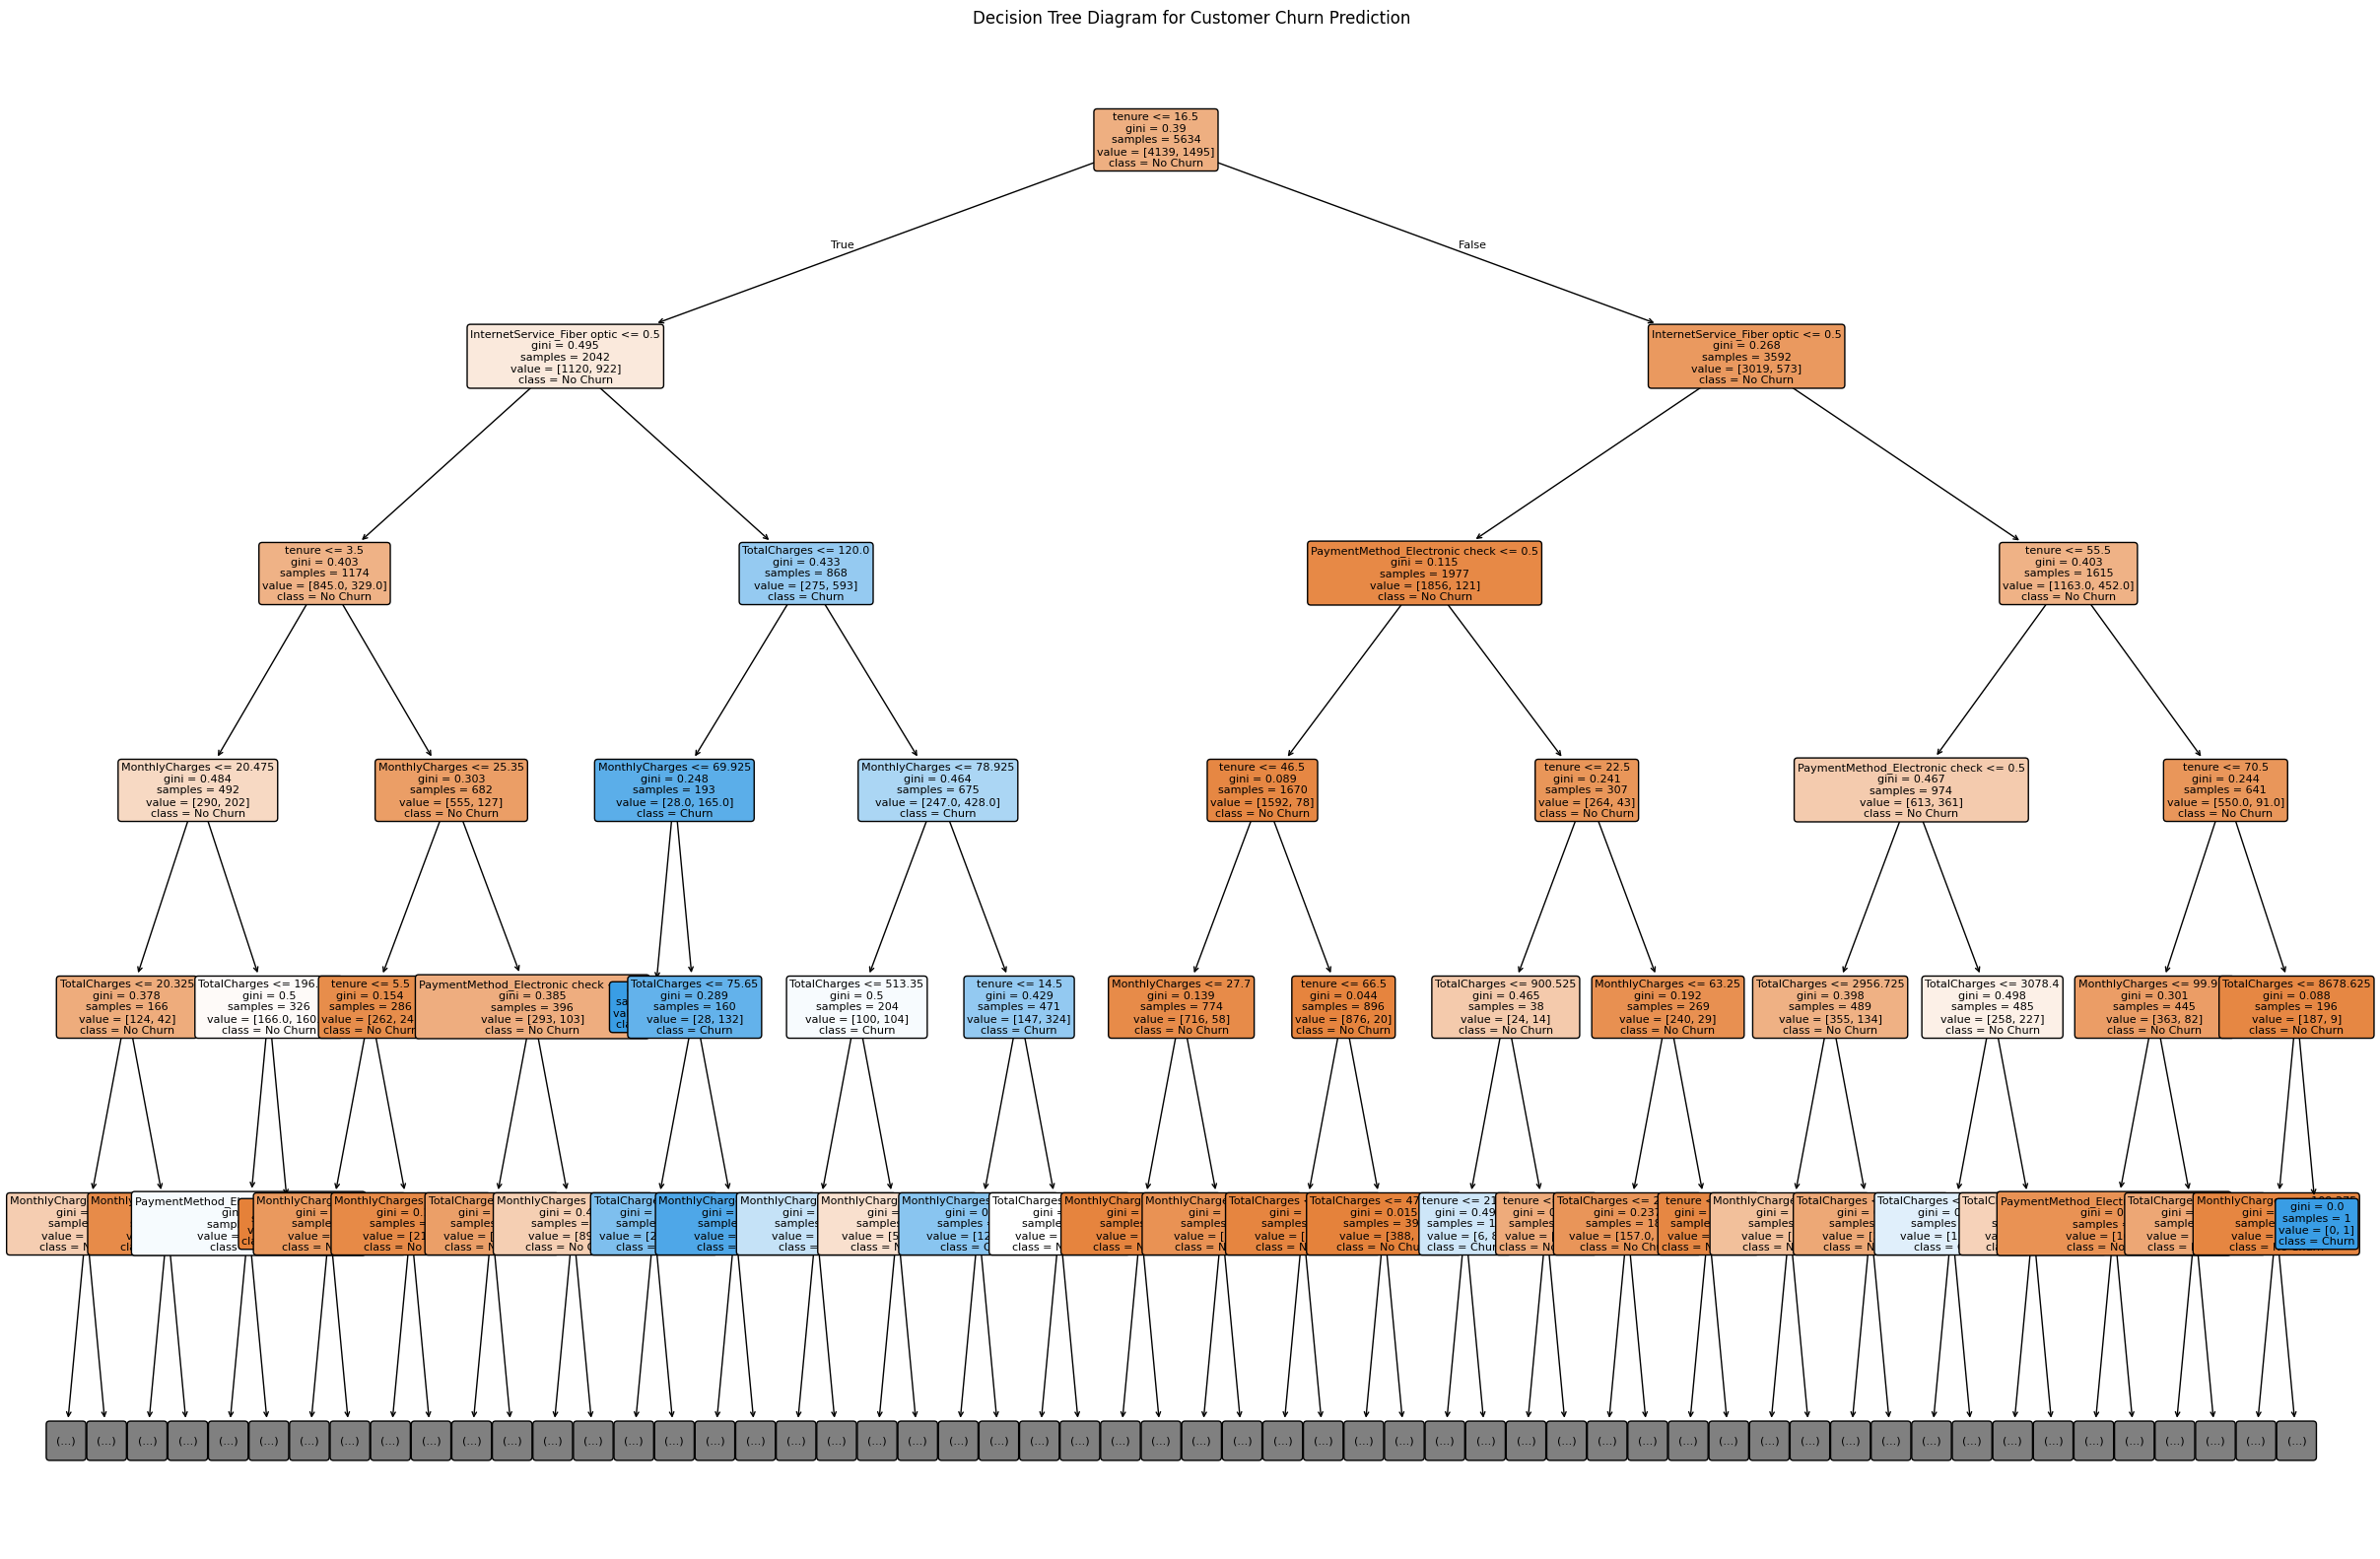

In [59]:
import matplotlib.pyplot as plt
from sklearn import tree
# Plot the trained Decision Tree model diagram using the reduced features
# feature_names displays the selexted dataset feature names
# class_names shows the meaning of the two target classes
# The max depth is set to 5 with appropriate size so that the diagram can be more
# readable and there is less overlapping between nodes
plt.figure(figsize=(30, 20))
tree.plot_tree(
    dt_reduced,
    feature_names=dt_selected_features,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    max_depth=5,
    fontsize=8)

plt.title("Decision Tree Diagram for Customer Churn Prediction")
plt.show()

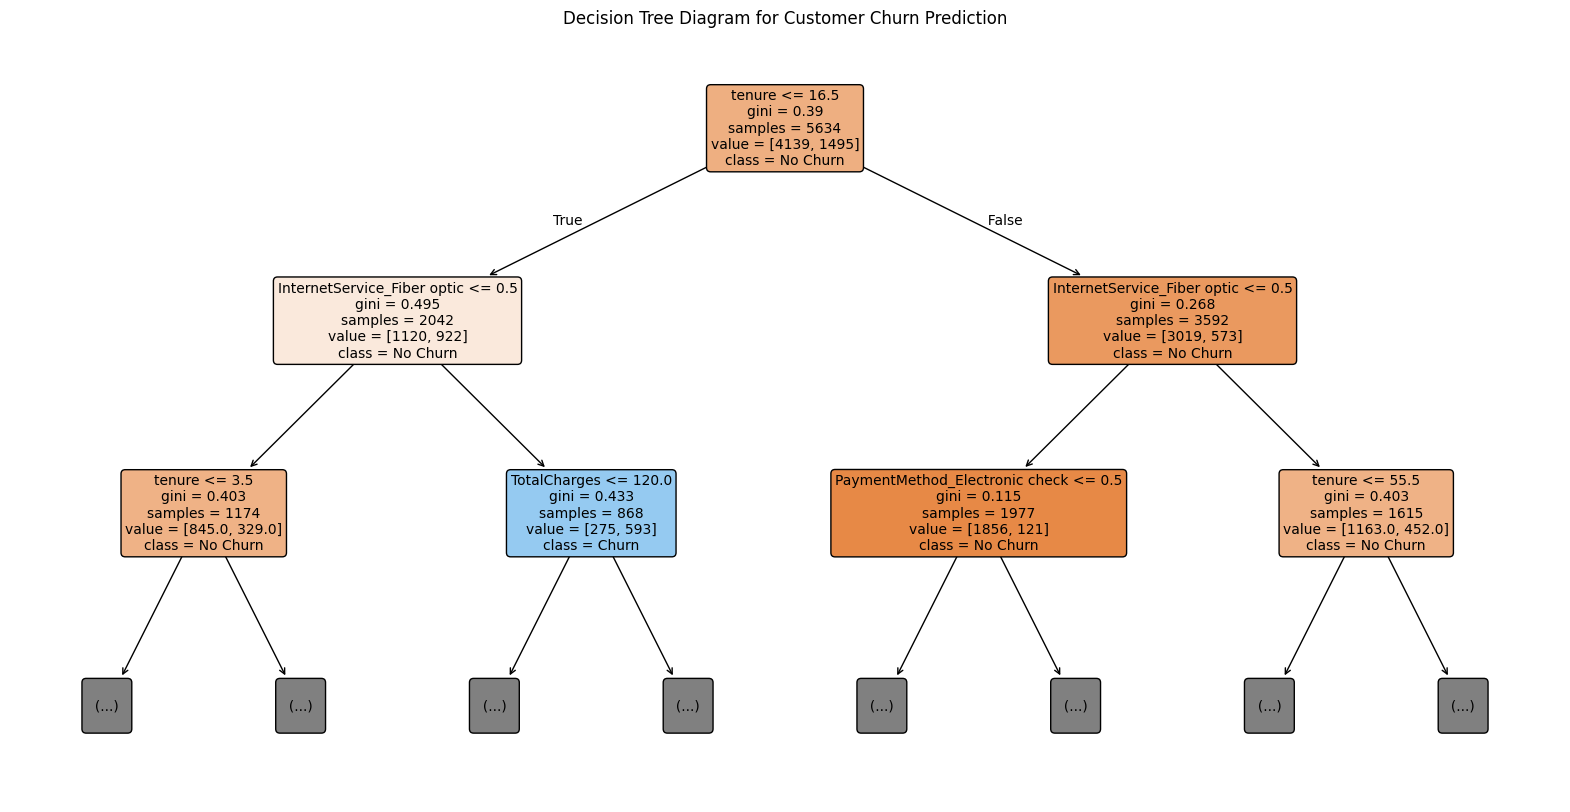

In [60]:
# This is for the decision tree diagram for adding in the report as a
# smaller version of the previous one
plt.figure(figsize=(20, 10))
tree.plot_tree(
    dt_reduced,
    feature_names=dt_selected_features,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=10)

plt.title("Decision Tree Diagram for Customer Churn Prediction")
plt.show()

The diagram has many branches and nodes and that is primarily due to the size and number of features in the dataset

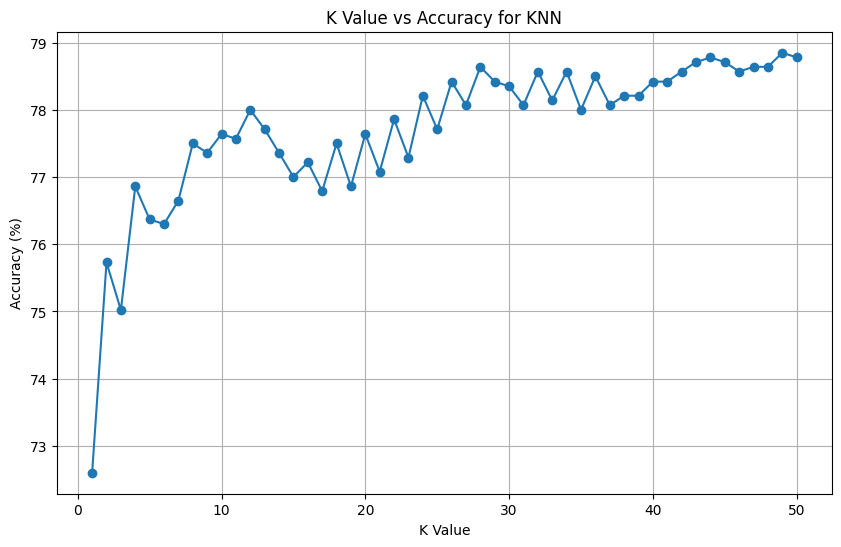

In [61]:
# Plotting K value against accuracy graph
# This graph shows how different K values affect the performance of the KNN model.
plt.figure(figsize=(10, 6))
plt.plot(k_results["K Value"], k_results["Accuracy"], marker="o")
plt.xlabel("K Value")
plt.ylabel("Accuracy (%)")
plt.title("K Value vs Accuracy for KNN")

plt.grid(True)
plt.show()

In [66]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# Predict probability scores for the positive class

dt_prob = dt_reduced.predict_proba(X_test_dt_selected)[:, 1]
knn_prob = knn_reduced.predict_proba(X_test_knn_selected_scaled)[:, 1]

In [67]:
# Calculate False Positive Rate, True Positive Rate, and thresholds
# for both Decision Tree and KNN models
dt_fpr, dt_tpr, dt_thresholds = roc_curve(y_test, dt_prob)
knn_fpr, knn_tpr, knn_thresholds = roc_curve(y_test, knn_prob)
# Calculate AUC values for both models
dt_auc = auc(dt_fpr, dt_tpr)
knn_auc = auc(knn_fpr, knn_tpr)

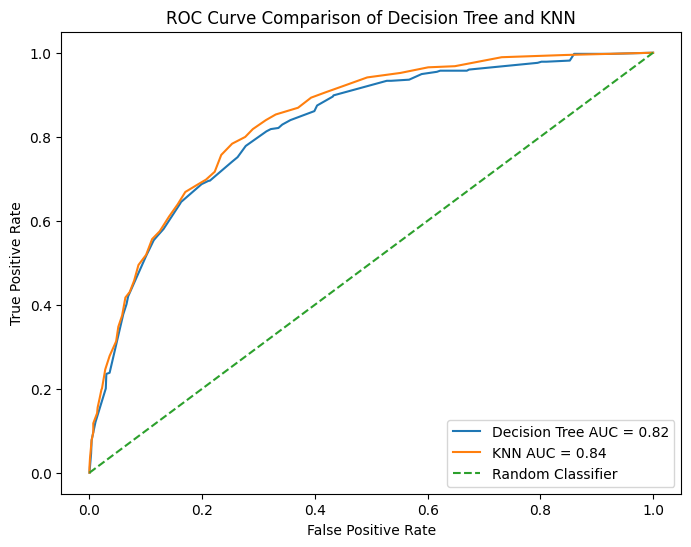

In [68]:
# Plot ROC curves for Decision Tree and KNN
# The diagonal dashed line represents random classification.
# A model with a curve closer to the top-left corner performs better.
plt.figure(figsize=(8, 6))
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree AUC = {dt_auc:.2f}")
plt.plot(knn_fpr, knn_tpr, label=f"KNN AUC = {knn_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Decision Tree and KNN")
plt.legend(loc="lower right")
plt.show()